=== MODELO BASE (Regresión Lineal) ===
MAE:      2.3232
R2 Score: 0.9140

=== MODELO OPTIMIZADO (Random Forest Regressor) ===
MAE:      4.3159
MSE:      31.7672
RMSE:     5.6362
R2 Score: 0.7130



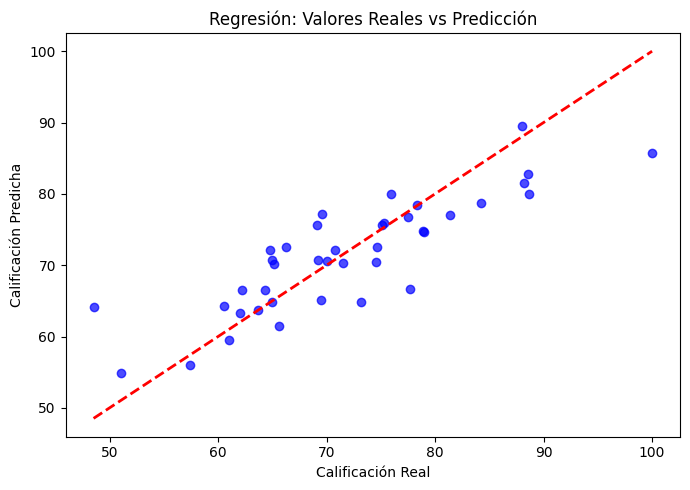

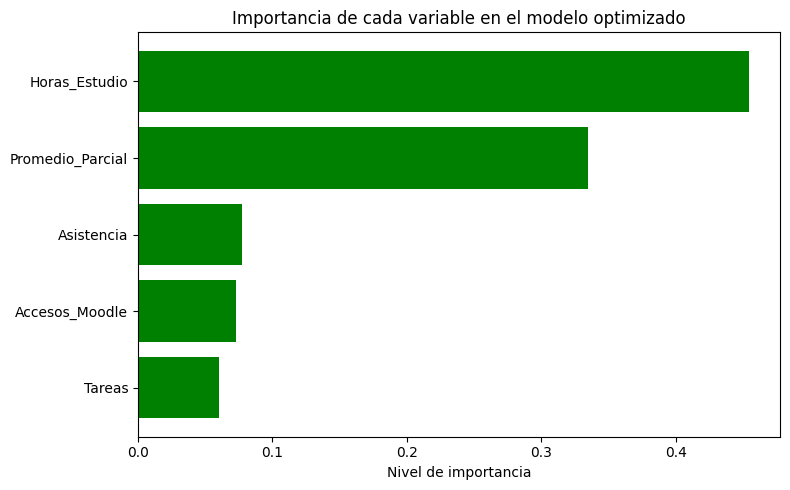

=== PREDICCIONES PARA NUEVOS ALUMNOS ===
Alumno 1: Calificación Final Predicha -> 76.42 pts
Alumno 2: Calificación Final Predicha -> 51.82 pts


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# -------------------------------------------------------------
# 1. CARGAR DATASET
# -------------------------------------------------------------
df = pd.read_csv("alumnos.csv")

# -------------------------------------------------------------
# 2. DEFINIR VARIABLES Y DIVIDIR DATOS
# -------------------------------------------------------------
X = df[
    [
        "Promedio_Parcial",
        "Asistencia",
        "Horas_Estudio",
        "Accesos_Moodle",
        "Tareas",
    ]
]
y = df["Calificacion_Final"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------------------------------------
# 3. MODELO BASE (Regresión Lineal)
# -------------------------------------------------------------
reg_base = LinearRegression()
reg_base.fit(X_train, y_train)
y_pred_base = reg_base.predict(X_test)

print("=== MODELO BASE (Regresión Lineal) ===")
print(f"MAE:      {mean_absolute_error(y_test, y_pred_base):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_base):.4f}\n")

# -------------------------------------------------------------
# 4. MODELO OPTIMIZADO (Random Forest Regressor)
# -------------------------------------------------------------
reg_opt = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
reg_opt.fit(X_train, y_train)
y_pred_opt = reg_opt.predict(X_test)

print("=== MODELO OPTIMIZADO (Random Forest Regressor) ===")
print(f"MAE:      {mean_absolute_error(y_test, y_pred_opt):.4f}")
print(f"MSE:      {mean_squared_error(y_test, y_pred_opt):.4f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_opt)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_opt):.4f}\n")

# Gráfica Reales vs Predicción
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_opt, color="blue", alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2
)
plt.xlabel("Calificación Real")
plt.ylabel("Calificación Predicha")
plt.title("Regresión: Valores Reales vs Predicción")
plt.tight_layout()
plt.savefig("grafica_regresion.png")
plt.show()

# -------------------------------------------------------------
# 5. IMPORTANCIA DE VARIABLES (La gráfica verde)
# -------------------------------------------------------------
importancias = reg_opt.feature_importances_
variables = X.columns

df_imp = pd.DataFrame(
    {"Variable": variables, "Importancia": importancias}
).sort_values("Importancia", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(df_imp["Variable"], df_imp["Importancia"], color="green")
plt.xlabel("Nivel de importancia")
plt.title("Importancia de cada variable en el modelo optimizado")
plt.tight_layout()
plt.savefig("importancia_regresion.png")
plt.show()

# -------------------------------------------------------------
# 6. PREDICCIONES CON NUEVOS ALUMNOS
# -------------------------------------------------------------
nuevos_alumnos = pd.DataFrame(
    [
        [85, 90, 8, 35, 8],  # Alumno 1
        [50, 65, 2, 10, 3],  # Alumno 2
    ],
    columns=X.columns,
)

predicciones = reg_opt.predict(nuevos_alumnos)

print("=== PREDICCIONES PARA NUEVOS ALUMNOS ===")
for i, pred in enumerate(predicciones):
  print(f"Alumno {i+1}: Calificación Final Predicha -> {pred:.2f} pts")